In [235]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import torch
import torch.nn.functional as F
import pandas as pd


*Disclaimer*: I think this post will make a lot more sense and have most value if you have a good foundation in linear regressions. That's my background and it's easiest for me to frame ML in the context of what I know. I do reference matrices a lot, so if you want a refresher on matrix multiplication, I really like this site: [https://matrixmultiplication.xyz/](https://matrixmultiplication.xyz/). 

## The model

I promised that the next blog posts would be more complex. Again, I'm going to fit simulated data using a ML model where there's an underlying linear model--albeit the function will be non-linear. Here, I will simulate data from a classic Gaussian Process (GP) model, which are most commonly analyzed under a Bayesian regression framework. (Remember, I come from a Bayesian background 😉. If you're interested in that, go check out [Stan's tutorial](https://mc-stan.org/docs/stan-users-guide/gaussian-processes.html).) 
$$
\begin{aligned}
y &\sim N(GP, \sigma) \\
GP &\sim MVN(0, K(d)) \\
[K(d)]_{ij} &= \eta^2 exp(-0.5/\rho^2 d_{ij}^2)
\end{aligned}
$$

I won't go too deep into the details of this model, but the general gist is that there's a GP intercept in the mean portion of the likelihood function (the normal distribution in the first line). The GP intercept is a latent function drawn from a multivariate normal distribution such that the covariance matrix, $K(d)$, decays with distance. Ultimately, it means that nearby data points--whether in time or space--are more similar to one another. I used these models extensively when I worked at USGS, modeling fine-scale spatial heterogeneity of fuels. While most ecologists want to control for spatial autocorrelation, I was interested in explicitly measuring it.

## The goal

In my previous blog post, I was fitting a quadratic function where I knew the underlying functional form, and the purpose was to estimate the parameters within that function. In this case, I want to approximate the function generating my data, without assuming a specific equation. To start, let's simulate the data. 



In [895]:
# choose parameters/data
ETA = 3
RHO = 10
SIGMA = .7
DIST = 50

Define functions to simulate data given the parameters defined above.

In [925]:

# locations of data
x = np.arange(-DIST, DIST, 0.5)  # from 0 to 60 step 0.5
N = len(x)

# Compute distance matrix
distMat = cdist(x.reshape(-1,1), x.reshape(-1,1), metric='euclidean')

# covariance kernel function
def fkernel(eta, rho, d):
    return eta**2 * np.exp(-0.5 * (d**2) / (rho**2))

# function to simulate data
def sampleGP(eta, rho, sigma, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # Kernel matrix
    K = fkernel(eta, rho, distMat)
    np.fill_diagonal(K, np.diag(K) + 1e-9)  # numerical stability

    # Simulate latent GP
    zGP = np.random.normal(size=N)
    L = np.linalg.cholesky(K)
    GP = L @ zGP

    # Simulate observations with normally distrib error
    y = np.random.normal(loc=GP, scale=sigma, size=N)

    return GP, y


Simulate the data and plot it.

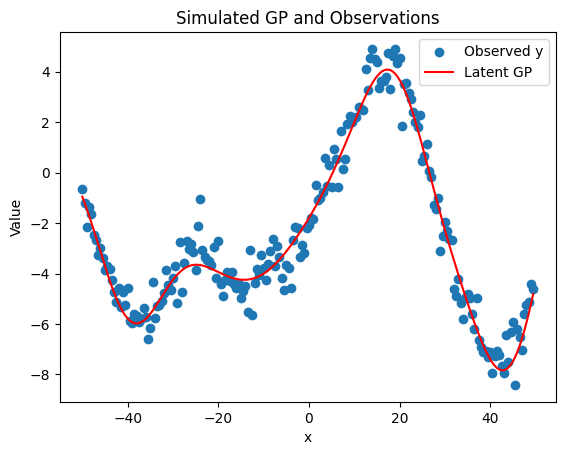

In [926]:
# simulate data
GP, y = sampleGP(ETA, RHO, SIGMA, seed=33) 

# Plot results
plt.scatter(x, y, label='Observed y')
plt.plot(x, GP, color='red', label='Latent GP')
plt.legend()
plt.xlabel('x')
plt.ylabel('Value')
plt.title('Simulated GP and Observations')
plt.show()

## Structure of a neural network

Neural networks at their core are also linear regressions.

$$
\begin{aligned}
\text{layer}_1 &= ReLU(XW_1 + b_1) \\
\text{layer}_2 &= ReLU(\text{layer}_1W_2 + b_2) \\
\hat{y} &= \text{layer}_2W_3 + b_3
\end{aligned}
$$ 

A neural network predicts an output, in this case $\hat{y}$ through a series of sequential and hierarchical linear models. 

Let's start with the first line in the model above. This line calculates the first **hidden layer** of the model. There's a data matrix $X$, which contain all of your predictor variables. In our GP example, there's only 1 column of data--the locations along the x-axis. But if you had a tabular dataset with multiple predictors, $X$ would be a matrix with $N$ rows (where $N$ = sample size) and $J$ columns (where $J$ = number of predictors). $W_1$ and $b_1$ are **weights** and **biases**, which are exactly the same as regression coefficients (remember $y = mx + b$?). Weights are coefficients that get multiplied by the input matrix and the bias is a constant value. Since $X$ is multiplied by $W_1$ with [matrix multiplication](http://matrixmultiplication.xyz/), the number of columns in $X$ must match the number of rows in $W_1$.

Then there's the ReLU, which applies a non-linear transformation and is more generally known as an **activation function**. Since the data forms a wiggly function, including this non-linear transformation is pretty important. Despite the fancy name, a ReLU is a very simple function: it takes input values and modifies any negative values to be zero. Let me show you. 

In [1058]:
vals = range(-4, 4)
transformed_vals = F.relu(torch.tensor(vals))
print(f"Original values: {list(vals)}")
print(f"Values that have been transformed with a ReLU: {transformed_vals}")

Original values: [-4, -3, -2, -1, 0, 1, 2, 3]
Values that have been transformed with a ReLU: tensor([0, 0, 0, 0, 0, 1, 2, 3])


What distinguishes a neural network from the simpler ML model that I produced in the blog post before is the hierarchical nature of these linear models. Just like the data matrix $X$ was multiplied by the weights in $\text{layer}_1$, $\text{layer}_1$ is treated as an input for the next layer and gets multipled by the weights in $\text{layer}_2$. Each layer has its own sets of weights and biases (e.g. $b_1 \neq b_2$). In the example above, I have 2 **hidden layers** and 1 **output layer**. Notice that each hidden layer is transformed by the ReLU function and the output layer is not. We skip the ReLU on the final layer because we want the output to take any value (not just non-negative values).

Neural networks can have an arbitrary number of hidden layers. I'm sure I'm ignoring nuances here, but the difference between a **neural network** and a **deep learning** model is that deep learning models are neural networks with many hidden layers. 

Additionally, inside each layer are things called **nodes**, sometimes also referred to as **neurons**. I like to think of nodes as the columns in the weight matrices. For example, if $W_1$ is a $J \times H_1$ matrix—where $J$ is the number of input features (or coefficients) and $H_1$ is the number of hidden units—then there are $H_1$ nodes in that first hidden layer. When we multiply $X$ (which is $N \times J$) by $W_1$, we get an $N \times H_1$ matrix, which means we’re calculating the output of all $H_1$ nodes at once using matrix multiplication. In the next layer, $W_2$ will have $H_1$ rows and $H_2$ columns, corresponding to $H_2$ nodes in the second hidden layer. Here, the weights in the final output layer will have only 1 node so that when it's multiplied by the layer's input, the resulting matrix product only has 1 column. 

I used to come across these pictures of neural networks and my eyes would glaze over. Now, I understand that they simply represent the matrix multiplication behind the model. The blue circles represent the input data. I show it having 2 circles, representing 2 coefficients. Each of these coefficients are multiplied by the $H_1$ nodes in first hidden layer, as shown in orange. That's what the arrows represent. The arrows between the rest of the layers also just represent matrix multiplication.

![A graphical representation of a basic neural network.](images/nn_structure_Page_2.jpg) 

## Write a neural network by scratch

Wow, that was a doozy! Hope you're still with me. With that, let's build our own neural network by scratch. In other blog posts, I'll use `fastai` or `pytorch` to model data, but building one yourself really helps to cement what's going on behind the scenes. It helps make the model less of a black box. 

To start, let's convert our data to tensors. Since $X$ can in theory have multiple coefficients, let's make it a 2-rank tensor (aka a matrix) and also make $y$ have the same dimensions. Another thing that is SUPER important is to standardize $X$. This is also true in linear regressions in general. I z-score it so that the mean is centered at 0 and has a SD of 1. When I was developing this blog post, I couldn't for the life of me get any sensible predictors before I standardized $X$. Do it.  


In [927]:
# standardize x
x_std = (x - x.mean())/(x.std())

# convert to 2-rank tensors (matrices)
x_std = torch.tensor(x_std[:,None], dtype=torch.float)
y = torch.tensor(y[:,None])

Like in the other blog post, I organize the gradient descent algorithm in a optimization class. The class here called `OptimizerNN` contains the same important functions: 

- `_calc_loss()`: loss + gradient calculation 
- `_adjust`: adjustment of parameters 
- `_zero`: zero out the gradients after parameters adjusted
- `_epoch` and `train`: helper functions that join all the steps in an epoch and train over many epochs/iterations

Outside that class, I've written 3 functions. 

1) `NN()` will be passed in the `OptimizerNN` class as the `model_fn` parameter. I've generalized the function to have an arbitrary number of hidden layers. Try to see how the code relates to the model equation that I wrote above.
2) `rmse()` is a loss function that we'll use to compare the predictions against the data. It's the same loss function I used in the other blog post. 
3) `init_pars()` initiates the weights and biases for each of the hidden layers with random values pulled from standard normal distribution. I also generalized the function so that it can accomodate an arbitrary number of hidden layers. There's one detail in how I initiated `W`, the weights. I multiplied the random values by `np.sqrt(2 / sizes[i])`, which is a common initialization trick called He initialization. This helps stabilize the variance of activations as they flow through the network, especially when using ReLU activation functions. Without it, I ran into issues. 


In [1071]:
# the model function
def NN(x, pars):
    weights, biases = pars
    layer = x
    for W, b in zip(weights[:-1], biases[:-1]):  # hidden layers
        layer = F.relu(layer @ W + b)
    return layer @ weights[-1] + biases[-1]  # output layer

# loss function
def rmse(obs: torch.tensor, pred: torch.tensor):
    sq_error = (obs - pred)**2
    return sq_error.mean().sqrt()

# initiate parameters with multiple hidden layers
def init_pars(x, H: list):
    n_coeffs= x.size(1)
    weights = []
    biases = []
    sizes = [n_coeffs] + H + [1]
    for i in range(len(sizes) - 1):
        W = torch.randn(sizes[i], sizes[i+1], dtype=torch.float) * np.sqrt(2 / sizes[i])
        b = torch.zeros(sizes[i+1], dtype=torch.float)
        W.requires_grad_()
        b.requires_grad_()
        weights.append(W)
        biases.append(b)
    return tuple(weights), tuple(biases)

# optimizer class for a NN with multiple hidden layers
class OptimizerNN:
    def __init__(self, x, y, pars, lr, model_fn=NN, loss_fn=rmse):
        self.x = x
        self.y = y
        self.pars = pars
        self.lr = lr
        self.model_fn = model_fn
        self.loss_fn = loss_fn
        self.loss_values = []
        self.pred_values = None

    def _calc_loss(self):
        # step 3 + 4--predict, calculate loss, get gradients
        y_hat = self.model_fn(self.x, self.pars)
        loss = self.loss_fn(self.y, y_hat)
        loss.backward()
        
        # store loss, prediction values
        self.loss_values.append(loss.item())
        self.pred_values = y_hat.detach().clone()
        

    def _adjust(self):
        # step 5
        weights, bias = self.pars
        for w, b in zip(weights, bias):
            w.data -= w.grad * self.lr
            b.data -= b.grad * self.lr
            
    def _zero(self):
        # step 6
        weights, bias = self.pars
        for w, b in zip(weights, bias):
            w.grad.zero_()
            b.grad.zero_()
    
    def _epoch(self):
        # step 7--all together
        self._calc_loss()
        self._adjust()
        self._zero()

    def train(self, nepochs):
        for i in range(0, nepochs):
            self._epoch()



To run this, you need to initiate the weights and biases with 2 parameters: `x`--the data--and `H`--the number of hidden units/neurons/nodes in each hidden layer. It takes a lot of fiddling, but I landed on `[32, 64, 64, 64, 64, 32]`. This means there are 6 hidden layers with the first layer having 32 nodes, etc. You can also play with the learning rate and number of epochs. You could probably reduce the loss by playing with all of these values more.


In [1073]:
# create parameters--weights and bias for each layer
torch.manual_seed(33) # set seed for reproducibility 
pars = init_pars(x_std, [32, 64, 64, 64, 64, 32])

# instantiate class
learning_rate = .005
opt = OptimizerNN(x_std, y, pars, learning_rate)

# train
nepochs = 8000
opt.train(nepochs)
print("RMSE: ", opt.loss_values[-1])


RMSE:  0.6245489467120209


As the model trained, it stored the loss values into a list. When I plot the loss with respect to the epochs, it continues dropping and starts to level out. 

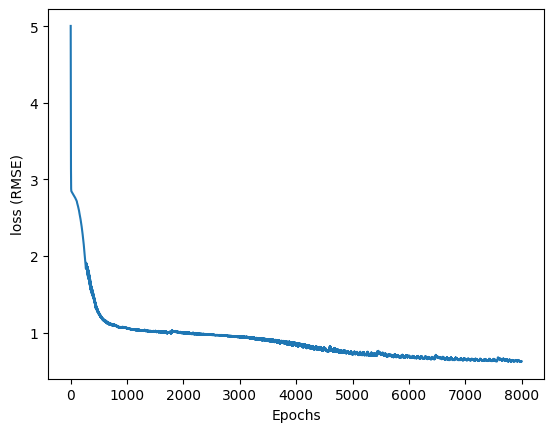

In [1076]:
# check out change in loss
loss_df = pd.DataFrame({'i': range(0, nepochs), 'loss': opt.loss_values})
plt.plot(loss_df['i'], loss_df['loss'])
plt.xlabel('Epochs')
plt.ylabel('loss (RMSE)')
plt.show()


And lastly, I can see how my predictions look against the data and the underlying GP model. It looks quite good, especially since I built this model by scratch! Congrats on making it to the end. Next posts, I promise to start using established packages to build NNs. 

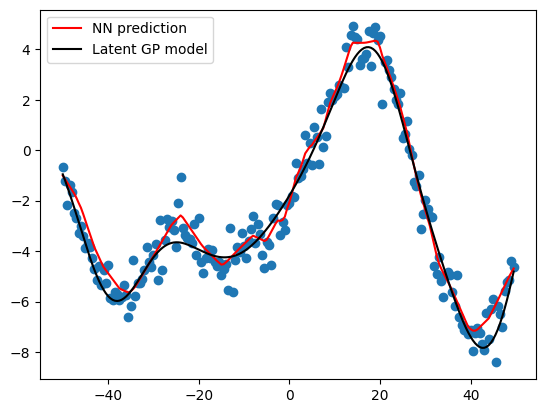

In [1075]:
# visualize the prediction values
plt.scatter(x, y)
plt.plot(x, (opt.pred_values), color = 'red', label = 'NN prediction')
plt.plot(x, GP, color = 'black', label = 'Latent GP model')
plt.legend()
plt.show()